In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [4]:
df=pd.read_csv('Customer-Churn-Records.csv')

In [6]:
df.shape

(10000, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [8]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [9]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [10]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

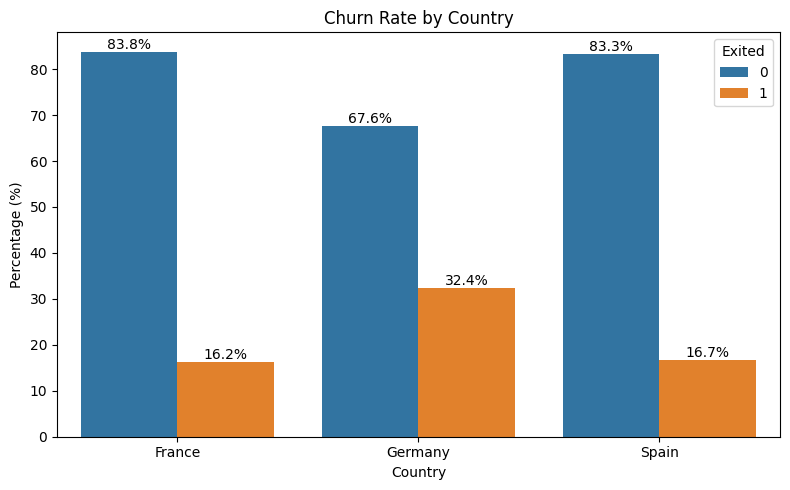

In [13]:
Country_Churn = (
    df.groupby('Geography')['Exited']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=Country_Churn,
    x='Geography',
    y='Percentage',
    hue='Exited'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Percentage (%)")
plt.legend(title="Exited")
plt.tight_layout()
plt.show()

### 🌍 Geography vs Customer Churn

#### Observation

- Germany recorded the highest customer churn rate among the three countries.
- France had the lowest churn rate, while Spain showed a moderate churn rate.
- Customer churn varies across different geographical regions.

#### Business Insight

The higher churn rate in Germany suggests that customers in this region are leaving the bank more frequently than those in France or Spain. However, this chart alone does **not** explain the reason for the higher churn. Additional analysis of factors such as customer age, account balance, activity status, number of products, or credit score within Germany is required to identify the root cause.

#### Recommendation

The bank should further investigate customer behavior in Germany and develop targeted retention strategies if specific customer segments are found to have a higher likelihood of leaving.


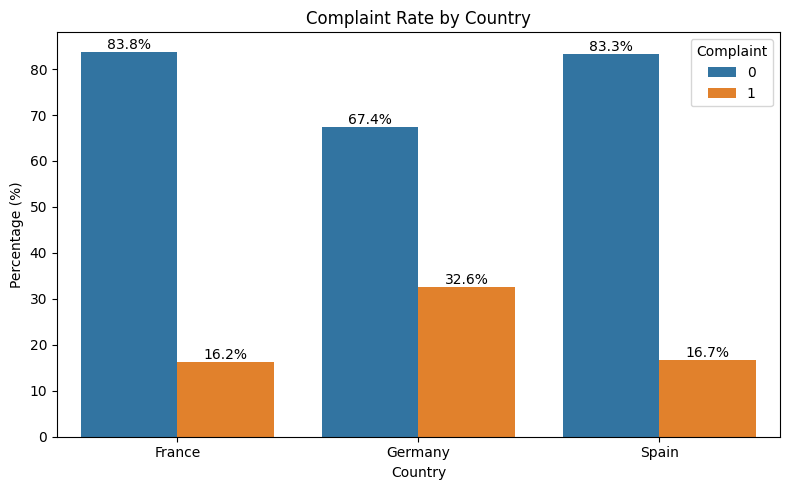

In [19]:
Complaint = (
    df.groupby('Geography')['Complain']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=Complaint,
    x='Geography',
    y='Percentage',
    hue='Complain'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title("Complaint Rate by Country")
plt.xlabel("Country")
plt.ylabel("Percentage (%)")
plt.legend(title="Complaint")
plt.tight_layout()
plt.show()

### 📞 Complaint Rate by Geography

#### Observation

- Germany recorded the highest complaint rate (32.6%) among the three countries.
- France (16.2%) and Spain (16.7%) had significantly lower complaint rates.
- Germany also showed the highest customer churn rate in the previous analysis.

#### Business Insight

The higher complaint rate in Germany may be associated with its higher customer churn rate. Customers experiencing more service issues or dissatisfaction could be more likely to leave the bank. However, this chart alone does not establish a direct cause-and-effect relationship.

#### Recommendation

The bank should investigate the nature of customer complaints in Germany and improve customer support and service quality. Further analysis should compare complaint rates between churned and retained customers to better understand their relationship with customer churn.

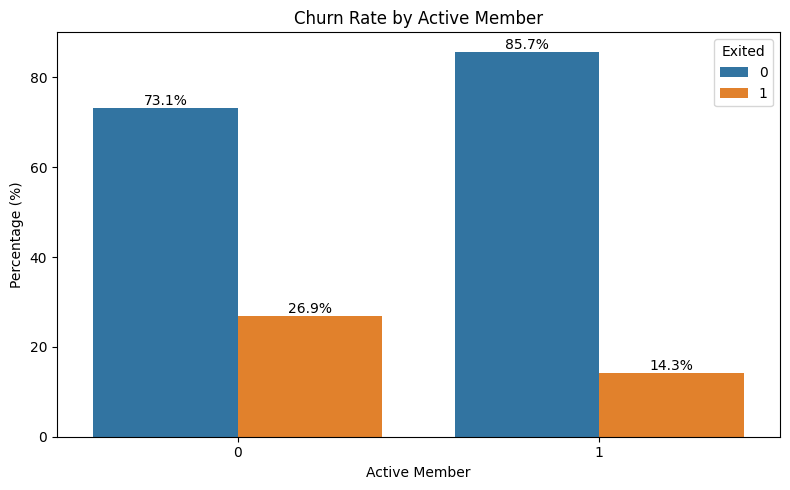

In [25]:
Active_Churn = (
    df.groupby('IsActiveMember')['Exited']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=Active_Churn,
    x='IsActiveMember',
    y='Percentage',
    hue='Exited'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title("Churn Rate by Active Member")
plt.xlabel("Active Member")
plt.ylabel("Percentage (%)")
plt.legend(title="Exited")
plt.tight_layout()
plt.show()

### 🟢 Active Member vs Customer Churn

#### Observation

- Inactive customers recorded a churn rate of **26.9%**, nearly twice that of active customers.
- Only **14.3%** of active customers left the bank.
- Active customers were significantly more likely to remain with the bank.

#### Business Insight

Customer engagement appears to play an important role in customer retention. Customers who actively use the bank's services are less likely to leave, while inactive customers are at a much higher risk of churning.

#### Recommendation

The bank should focus on increasing customer engagement by encouraging regular account usage, promoting digital banking services, offering personalized rewards, and launching re-engagement campaigns for inactive customers. Improving customer activity may help reduce churn and increase long-term customer retention.

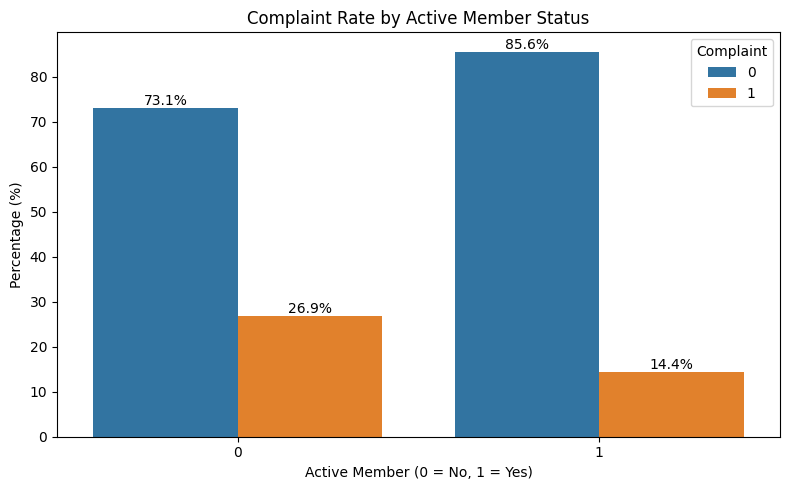

In [26]:
Active_Complaint = (
    df.groupby('IsActiveMember')['Complain']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=Active_Complaint,
    x='IsActiveMember',
    y='Percentage',
    hue='Complain'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title("Complaint Rate by Active Member Status")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.legend(title="Complaint")
plt.tight_layout()

plt.show()

### 📞 Complaint Rate by Active Member Status

#### Observation

- Inactive customers reported a complaint rate of **26.9%**, while active customers reported a much lower complaint rate of **14.4%**.
- Active customers were significantly less likely to raise complaints.

#### Business Insight

Inactive customers tend to experience or report more service issues than active customers. This suggests that lower customer engagement may be associated with a higher likelihood of complaints, which could contribute to customer churn.

#### Recommendation

The bank should proactively identify inactive customers and improve customer engagement through personalized communication, loyalty programs, and faster complaint resolution to reduce churn risk.

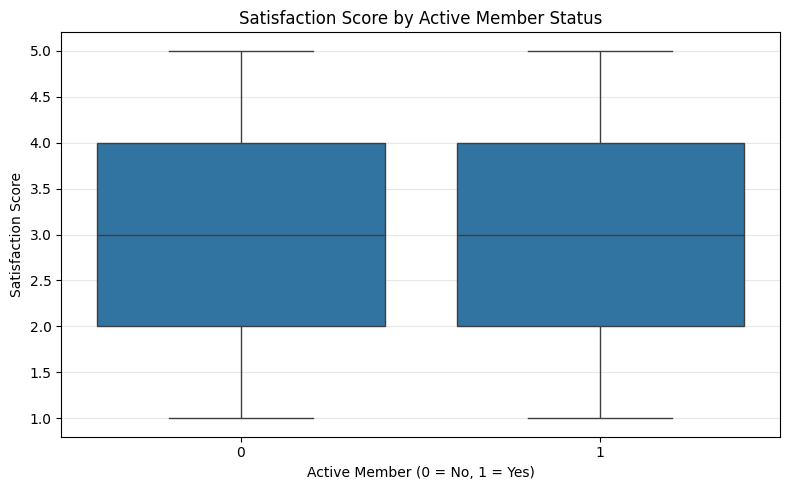

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='IsActiveMember',
    y='Satisfaction Score'
)

plt.title("Satisfaction Score by Active Member Status")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Satisfaction Score")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [28]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


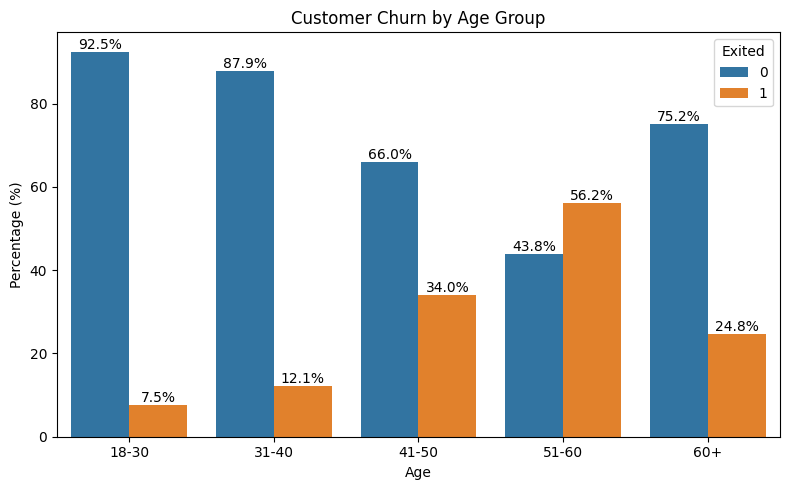

In [35]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)


Age_Churn = (
    df.groupby('Age_Group')['Exited']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=Age_Churn,
    x='Age_Group',
    y='Percentage',
    hue='Exited'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title("Customer Churn by Age Group")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Exited")
plt.tight_layout()
plt.show()

### 👥 Age Group vs Customer Churn

#### Observation

- Customers aged **18–30** and **31–40** recorded the lowest churn rates of **7.5%** and **12.1%**, respectively.
- Customer churn increased significantly for the **41–50** age group.
- The **51–60** age group recorded the highest churn rate at **56.2%**.
- Churn decreased for customers aged **60+**, although it remained higher than the younger age groups.

#### Business Insight

Middle-aged customers, particularly those between **51 and 60 years**, are considerably more likely to leave the bank than younger customers. This customer segment represents the highest churn risk and should be prioritized for retention efforts.

#### Recommendation

The bank should develop targeted retention strategies for customers aged **41–60**, such as personalized financial products, relationship management, loyalty rewards, and proactive customer engagement to reduce churn.

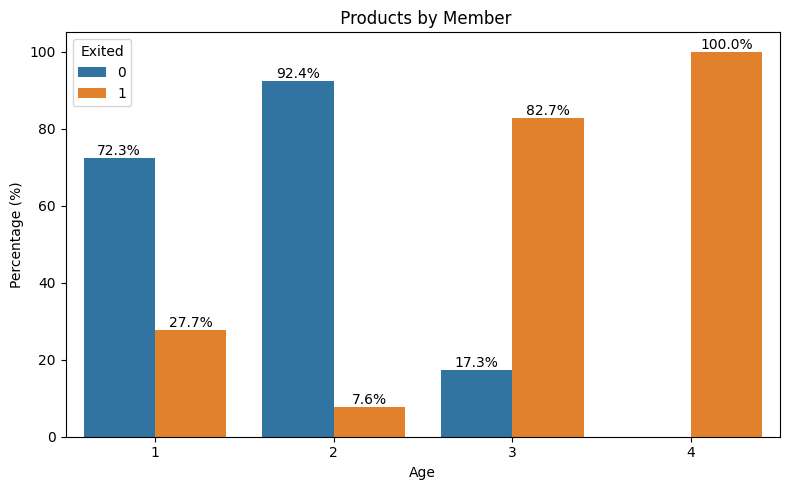

In [36]:
Product_Churn = (
    df.groupby('NumOfProducts')['Exited']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=Product_Churn,
    x='NumOfProducts',
    y='Percentage',
    hue='Exited'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title(" Products by Member")
plt.xlabel("Number of Products")
plt.ylabel("Percentage (%)")
plt.legend(title="Exited")
plt.tight_layout()
plt.show()

### 🏦 Number of Products vs Customer Churn

#### Observation

- Customers with **2 banking products** recorded the lowest churn rate (**7.6%**), indicating the highest customer retention.
- Customers with **1 product** showed a higher churn rate (**27.7%**).
- Customers owning **3 products** experienced a significantly higher churn rate (**82.7%**).
- Customers with **4 products** showed the highest churn rate. This result should be interpreted carefully if the number of customers in this category is small.

#### Business Insight

Customers using **two banking products** appear to be the most loyal segment. In contrast, customers with three or more products exhibit much higher churn rates. This suggests that customers with multiple products may require additional attention to understand whether service complexity, product fit, or other factors are contributing to their decision to leave.

#### Recommendation

The bank should encourage customers to adopt a second banking product, as this group demonstrates the strongest retention. Additionally, the bank should investigate why customers with three or more products are leaving and improve their experience through personalized relationship management and targeted retention strategies.

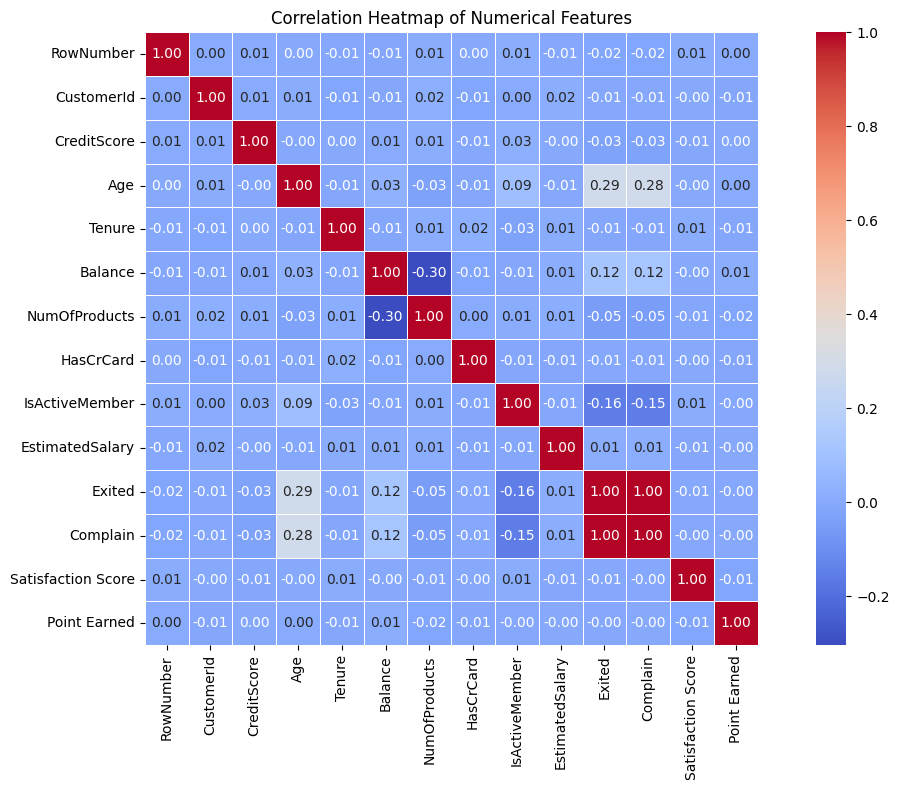

In [41]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### 🔥 Correlation Heatmap

#### Observation

- The correlation heatmap shows that most numerical features have **weak to moderate correlations**, indicating that customer churn is influenced by multiple factors rather than a single variable.
- **Age** exhibits the strongest positive correlation with customer churn (**0.29**), suggesting that older customers are more likely to leave the bank.
- **Complaint** is also positively correlated with customer churn (**0.28**), indicating that customers who raise complaints are more likely to churn.
- **IsActiveMember** has a negative correlation (**-0.16**) with customer churn, showing that active customers are less likely to leave the bank.
- **Balance** shows a weak positive relationship (**0.12**) with churn, while **Credit Score**, **Tenure**, **Estimated Salary**, **Card Ownership**, and **Satisfaction Score** exhibit little to no correlation with customer churn.
- **Balance** and **Number of Products** show a moderate negative correlation (**-0.30**), suggesting customers with higher balances generally own fewer banking products.

#### Business Insight

The heatmap confirms that customer churn is driven by a combination of customer behavior rather than a single financial metric. Factors such as **customer age**, **complaints**, and **activity status** have a stronger relationship with churn than variables like **credit score**, **salary**, or **tenure**. These findings support the earlier exploratory analysis and highlight the importance of customer engagement and service quality in improving customer retention.

# 📋 Executive Summary

This project presents an Exploratory Data Analysis (EDA) of a Bank Customer Churn dataset to identify the key factors influencing customer attrition. The primary objective was to understand customer behavior, discover patterns associated with churn, and provide actionable business recommendations that can help improve customer retention.

The analysis revealed that customer churn is influenced more by customer engagement and behavioral factors than by financial attributes alone. Variables such as geography, customer complaints, activity status, age, and the number of banking products showed meaningful relationships with churn, while factors such as card type, tenure, credit score, and estimated salary had little impact.

The findings provide valuable insights that can help the bank identify high-risk customers and implement targeted retention strategies.

---

# 🔍 Key Findings

- Germany recorded the highest customer churn rate among all geographical regions.
- Germany also had the highest customer complaint rate, indicating a possible relationship between service quality and customer attrition.
- Inactive customers were significantly more likely to leave the bank than active customers.
- Inactive customers also reported considerably more complaints than active customers.
- Customers aged **51–60 years** exhibited the highest churn rate, making them the most vulnerable customer segment.
- Customers holding **two banking products** showed the strongest customer retention, while churn increased substantially among customers with three or more products.
- The correlation heatmap confirmed that **Age**, **Complaint**, and **IsActiveMember** had stronger relationships with customer churn than variables such as credit score, tenure, salary, or card type.
- Customer churn appears to be driven by a combination of behavioral and engagement-related factors rather than a single financial attribute.

---

# 💼 Business Recommendations

### 1. Improve Customer Engagement
- Launch personalized campaigns targeting inactive customers.
- Encourage regular usage of digital banking services through rewards and incentives.

### 2. Strengthen Customer Support
- Closely monitor customer complaints and resolve issues quickly.
- Identify customers with repeated complaints and proactively engage with them before they decide to leave.

### 3. Focus on High-Risk Customer Segments
- Develop customized retention programs for customers aged **41–60 years**, especially those between **51–60 years**.
- Assign relationship managers to customers identified as high churn risks.

### 4. Encourage Multi-Product Adoption
- Promote cross-selling strategies that encourage customers to adopt a second banking product.
- Investigate why customers with three or more products exhibit significantly higher churn rates.

### 5. Region-Specific Retention Strategy
- Conduct a detailed investigation into customer behavior and service quality in **Germany**.
- Implement region-specific customer retention initiatives where churn and complaint rates are highest.

### 6. Build Predictive Churn Models
- Utilize important features such as customer age, complaints, activity status, and product usage to develop machine learning models capable of identifying customers at high risk of churning.

---

# ✅ Conclusion

The exploratory analysis successfully identified several factors associated with customer churn. Customer engagement, complaints, age, geography, and product usage emerged as the most influential factors affecting customer retention. In contrast, variables such as card type, tenure, credit score, and estimated salary showed little relationship with customer churn.

The analysis demonstrates that reducing customer churn requires a customer-centric approach focused on improving engagement, enhancing service quality, resolving complaints promptly, and implementing targeted retention strategies for high-risk customer segments.

Overall, this project highlights how data-driven insights can support better business decisions, improve customer satisfaction, and strengthen long-term customer retention strategies within the banking sector.